<a href="https://colab.research.google.com/github/KaueOPG/DCC008---Calculo-Numerico/blob/main/Trabalho4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Grupo:
1 - Kauê Oliveira Paraízo Garcia - 202265517B

2 - João Pedro Barbosa Coelho - 202369012D

#Pré-requisitos

As seguintes bibliotecas foram instaladas e importadas:

In [ ]:
from scipy.integrate import quad

#Trabalho Pratico 4 - Aproximações de Funções e Integração



In [ ]:
from numpy import polyfit
from numpy import polyval
from numpy import linspace
from numpy import zeros
from numpy import size

In [ ]:
import sympy as sp
from sympy import symbols
from sympy import diff
from sympy import N

In [ ]:
from math import ceil
from math import sqrt
from math import log

In [ ]:
import matplotlib.pyplot as plt

#Ajustes de Curvas

Questão 1

Através da função np.linspace(a,b,tam) geramos um vetor x com x(1) = a e x(tam) = b e componentes intermediários igualmente espaçados.

In [ ]:
t=linspace(5,18, 1024)
t

array([ 5.        ,  5.01270772,  5.02541544, ..., 17.97458456,
       17.98729228, 18.        ])

Criamos um vetor u em que cada elemento representa um valor x(idade) para outro valor y(peso) de indicices iquais no vetor v, representando a tabela dada.

In [ ]:
u=(6,7,8,9,10,11,12,13,14,15,16)
v=(0.029, 0.052, 0.079, 0.125, 0.181, 0.261, 0.425, 0.738, 1.130, 1.882, 2.812 )
print(u)
print(v)

(6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16)
(0.029, 0.052, 0.079, 0.125, 0.181, 0.261, 0.425, 0.738, 1.13, 1.882, 2.812)


Para encontra o melhor polinômio p de ordem n que que aproxima os pontos (x, y) no sentido dos mínimos quadrados utilizamos a função np.polyfit(x,y,n).

Após a análise dos dados, pode-se perceber que o polinômio que apresenta como  o mais adequado é o de maior grau.

---



Questão 2

Definindo a função definida no intervalo [−1, 1], $f(x) =\frac{1}{1+25x^2}$:

In [ ]:
def g(x):
  return 1/(1+25*x**2)

Definindo a função interp que calcula o polinõmio interpolador:

In [ ]:
def interp(u,v, x):
  N=size(u)
  s=0
  for i in range(N):
    r=1
    for k in range(N):
      if k!=i:
        r=r*(x-u[k])/(u[i]-u[k])
    s=s+v[i]*r
  return s

Definição da função sample que define a tabela de pontos para cada n:

In [ ]:
def sample(f, u):
  N=size(u)
  v=zeros(N)
  for k in range(N):
    v[k]=f(u[k])
  return v

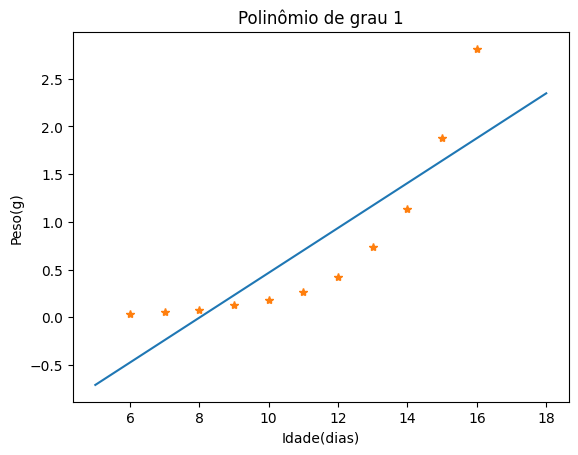

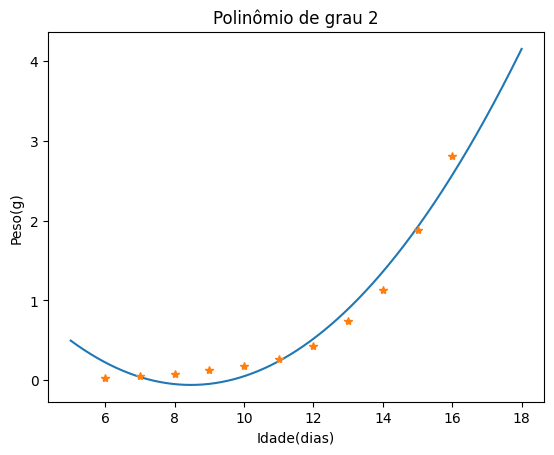

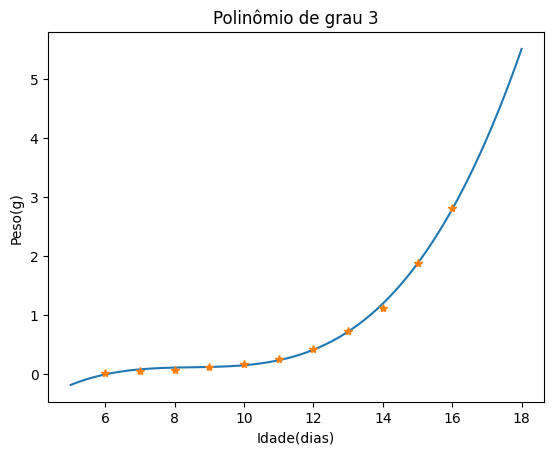

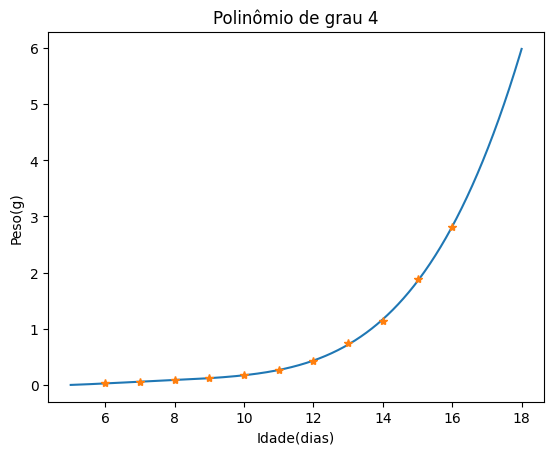

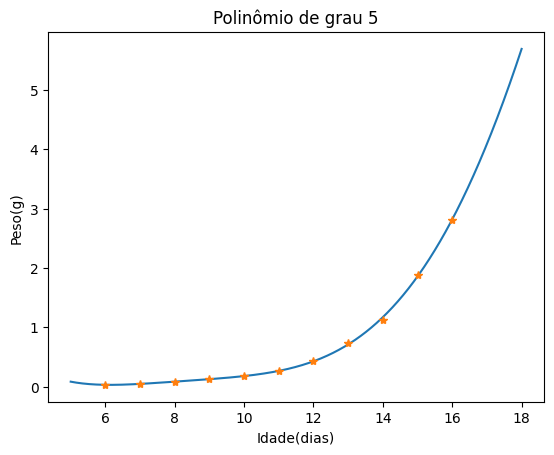

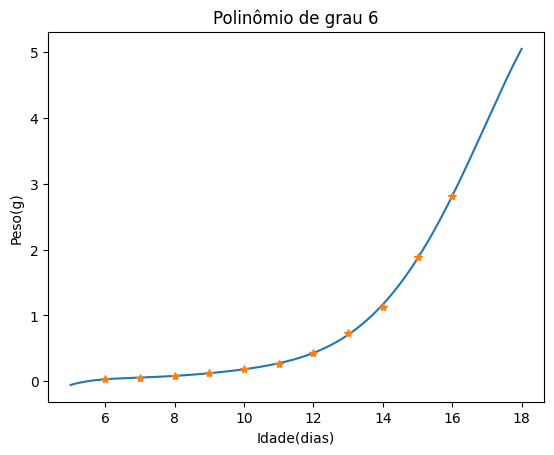

In [ ]:
for n in range(1,7):
  P=polyval(polyfit(u, v, n),t)
  fig, axe = plt.subplots()
  axe.set_xlabel('Idade(dias)')
  axe.set_ylabel('Peso(g)')
  titulo = 'Polinômio de grau ' + str(n)
  plt.title(titulo)
  plt.plot(t, P)
  plt.plot(u,v,'*')
  plt.show()

In [ ]:
x=linspace(-1,1,1024)
y=sample(g,x)

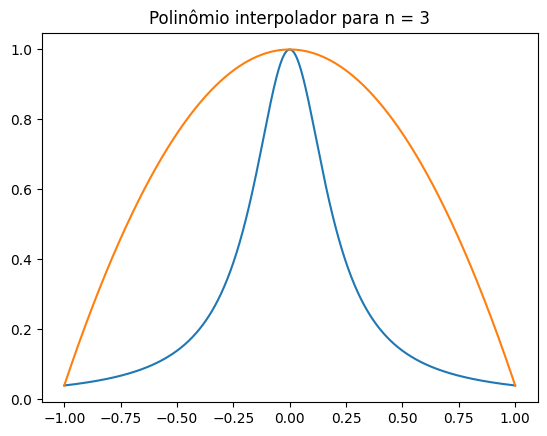

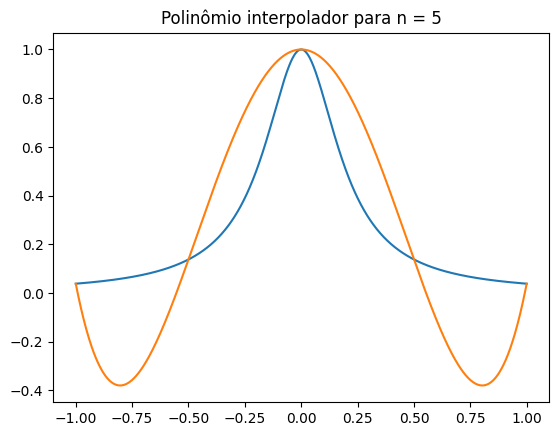

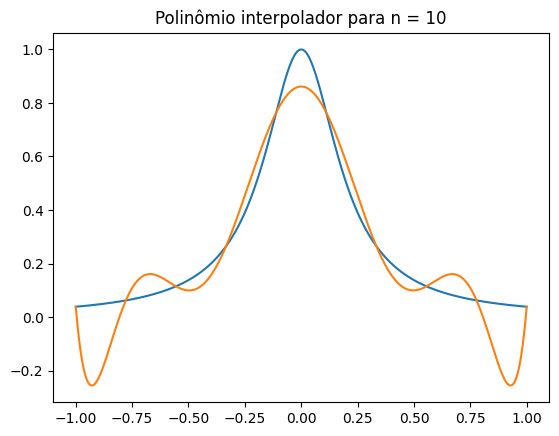

In [ ]:
N=[3,5,10]
for i in range(0,3):
  u=linspace(-1,1,N[i])
  v=sample(g,u)
  Y=interp(u,v,x)
  titulo = 'Polinômio interpolador para n = ' + str(N[i])
  plt.title(titulo)
  plt.plot(x, y)
  plt.plot(x, Y)
  plt.show()

Em um polinômio interpolador, como se diz no Fenômeno de Runge, a medida de pontos define o grau desse, com demostra os gráficos em que para três pontos ele toma uma função de grau 2, já medida que aumenta a quantidade de pontos o grau dele também aumenta. Ademais, também se percebe que a medida que se aumenta o grau do polinômio, ele tende a se aproximar mais da função real, como se percebe entre o n = 3 para n = 5. Entretanto, ao só adicionar pontos regularmente espaçados, o polinômio de maior grau tende a gerar um erro maior que os anteriores, como se percebe do n = 5 para n = 10, perto do ponto x = 0, o polinômio de maior grau se distância mais do que o de menor.

#Integração Numérica

Questão 1

Definição das regras de quadratura de Newton-Cotes, sendo f, a função a ser integrada, o intervalo de integração (a e b) e o numero de subdivisões m:

Trapézio: $\frac{(b-a)^2}{2}(f0 + f1)$

1/3 de Simpson: $\frac{(b-a)^2}{6}(f0 + 4f1 + f2)$

3/8 de Simpson: $\frac{(b-a)^2}{8}(f0 + 3f1 +3f2 + f3)$

In [ ]:
def Trapezio(f, a, b, m):
  h= (b-a)/m
  A=0
  for k in range(m):
    A=A+h*(f(a+k*h)+f(a+(k+1)*h))/2
  return A

def Simpson_13(f, a, b, m):
  H= (b-a)/m
  A=0
  for k in range(m):
    A=A+H/6*(f(a+k*H)+4*f(a+(k+1/2)*H)+f(a+(k+1)*H))
  return A

def Simpson_38(f, a, b, m):
  H= (b-a)/m
  A=0
  for k in range(m):
    A=A+H/8*(f(a+k*H)+3*f(a+(k+1/3)*H)+3*f(a+(k+2/3)*H)+f(a+(k+1)*H))
  return A

Questão 2

Definição da função $f(x) = x^2log(x^2+1)$

In [ ]:
def f(x):
  return x**2*log(x**2+1)

Encontrando de $f''(x)$ e $f''''(x)$:

In [ ]:
x=symbols('x')

In [ ]:
F= x**2*sp.ln(x**2+1)
F

x**2*log(x**2 + 1)

In [ ]:
dF=diff(F)
d2F= diff(dF)
d3F= diff(d2F)
d4F= diff(d3F)

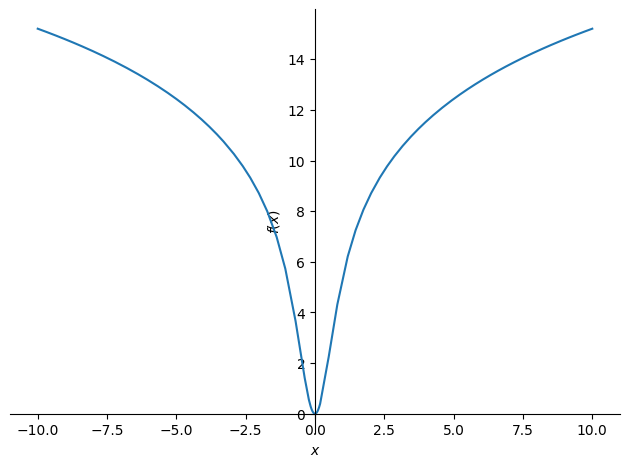

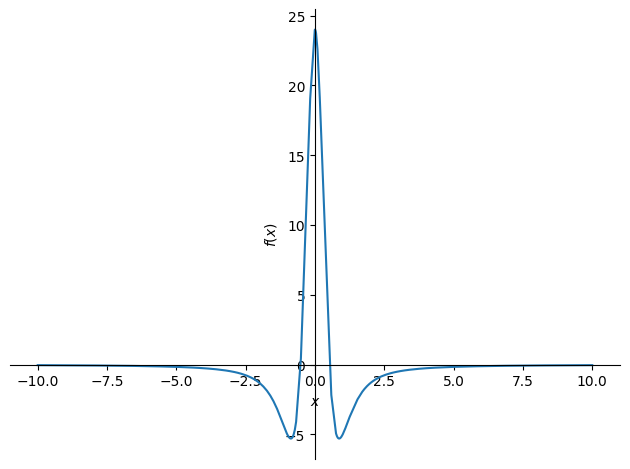

In [ ]:
sp.plot(d2F)
sp.plot(d4F)

In [ ]:
M2 = N(d2F.subs(x,2))
M4=N(d4F.subs(x,0))
print("f''(2) =",M2)
print("f''''(0) = ", M4)

f''(2) = 8.65887582486820
f''''(0) =  24.0000000000000


Após a nálise dos gráficos perceb-se que no intervalo [0, 2]  $f''(x)$   tem máximo em x=2 e  $f''''(x)$  tem máximo em x = 0, sendo eles 8,66 e 24 aproximadamente.

Utilizando a função quad(f, a, b) é possivel obter o resultado e o erro dessa integral f, de a até b:

In [ ]:
I, J=quad(f, 0, 2)
print('Resultado = ', I)
print('Erro = ', J)

Resultado =  3.1092908435170967
Erro =  3.130910781132753e-12


Utilizando um erro E e o intervalo (a,b):

In [ ]:
e=10**-4
a=0
b=2

Trapézio:

In [ ]:
#Número de subintervalos
n1=ceil(sqrt(M2/12*(b-a)**3/e))
print('Subintervalos = ',n1)

#Cálculo de I
I1=Trapezio(f, a, b, n1)
print('I1 = ',I1)

#Cálculo do erro
Erro1=I-I1
print('Erro1 = ',Erro1)

#Cálculo do limite do erro
Limite_Erro1=M2/12*n1*((b-a)/n1)**3
Limite_Erro1
if abs(Erro1) < Limite_Erro1:
  print('Erro menor que o limite, com uma diferença de ', Limite_Erro1 - abs(Erro1))
else:
  print('Erro maior que o limite')

Subintervalos =  241
I1 =  3.109346155633807
Erro1 =  -5.5312116710393155e-05
Erro menor que o limite, com uma diferença de  4.40763904304183e-5


1/3 de Simpson:

In [ ]:
#Número de subintervalos
n2=ceil((M4/2880/e*(b-a)**5)**(1/4))
print('Subintervalos = ',n2)

#Cálculo de I
I2=Simpson_13(f, a, b, n2)
print('I2 = ',I2)

#Cálculo do erro
Erro2=I-I2
print('Erro2 = ',Erro2)

#Cálculo do limite do erro
Limite_Erro2=M4/90*n2*((b-a)/n2/2)**5
Limite_Erro2
if abs(Erro2) < Limite_Erro2:
  print('Erro menor que o limite, com uma diferença de ', Limite_Erro2 - abs(Erro2))
else:
  print('Erro maior que o limite')

Subintervalos =  8
I2 =  3.10929379080616
Erro2 =  -2.94728906080621e-6
Erro menor que o limite, com uma diferença de  6.21568776058605e-5


3/8 de Simpson:

In [ ]:
#Número de subintervalos
n3=ceil((M4/6480/e*(b-a)**5)**(1/4))
print('Subintervalos = ',n3)

#Cálculo de I
I3=Simpson_38(f, a, b, n3)
print('I3 = ',I3)

#Cálculo do erro
Erro3=I-I3
print('Erro3 = ',Erro3)

#Cálculo do limite do erro
Limite_Erro3=3*M4/80*n3*((b-a)/n3/3)**5
Limite_Erro3
if abs(Erro3) < Limite_Erro3:
  print('Erro menor que o limite, com uma diferença de ', Limite_Erro3 - abs(Erro3))
else:
  print('Erro maior que o limite')

Subintervalos =  6
I3 =  3.10929497986149
Erro3 =  -4.13634438833910e-6
Erro menor que o limite, com uma diferença de  8.73131297771845e-5


Comparando os resultados com a função quad percebe-se que o 3/8 de Simpson foi o que teve o menor erro com o menor número de interações, enquanto o trapézio foi o que utilizou o maior número de interações e o maior erro.

In [ ]:
print('I - I1 :',I - I1)
print('I - I2 :',I - I2)
print('I - I3 :',I - I3)

I - I1 : -5.5312116710393155e-05
I - I2 : -2.94728906080621e-6
I - I3 : -4.13634438833910e-6
